In [1]:
from sympy import *
import scipy
import matplotlib.pyplot as plt
import numpy as np

**Задание 1**

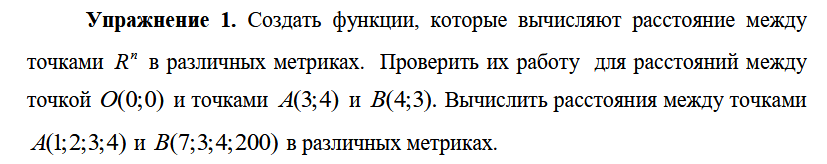

In [7]:
def p(point1, point2, type=0):
    match type:
        case 0:
            r = 0
            for k in range(0, len(point1)):
                if abs(point2[k] - point1[k]) > r:
                    r = abs(point2[k] - point1[k])
            return r
        case 1:
            r = 0
            for k in range(0, len(point1)):
                r += abs(point2[k] - point1[k])
            return r
        case 2:
            r = 0
            for k in range(0, len(point1)):
                r += (point2[k] - point1[k])**2
            return r**0.5


O = np.array([0,0])
A = np.array([3,4])
B = np.array([4,3])
for type in range(3):
    print(f"p{type}: OA = {p(O,A,type)}, OB = {p(O,B,type)}")
A = np.array([1,2,3,4])
B = np.array([7,3,4,200])
for type in range(3):
    print(f"p{type}: AB = {p(A,B,type)}")

p0: OA = 4, OB = 4
p1: OA = 7, OB = 7
p2: OA = 5.0, OB = 5.0
p0: AB = 196
p1: AB = 204
p2: AB = 196.0969148150985


**Задание 2**

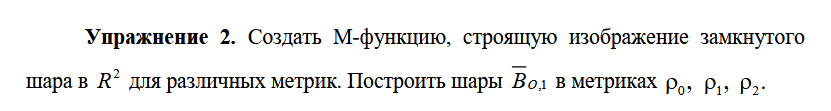

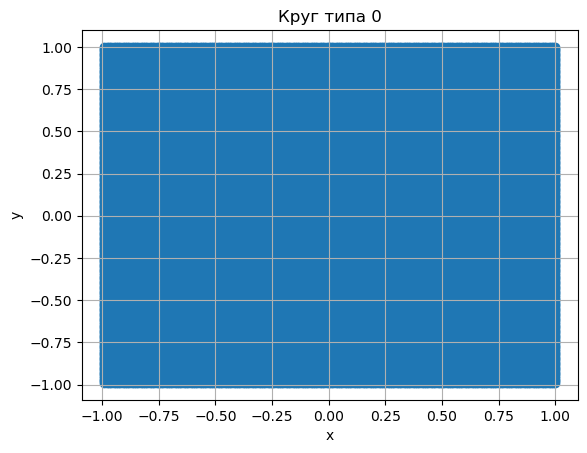

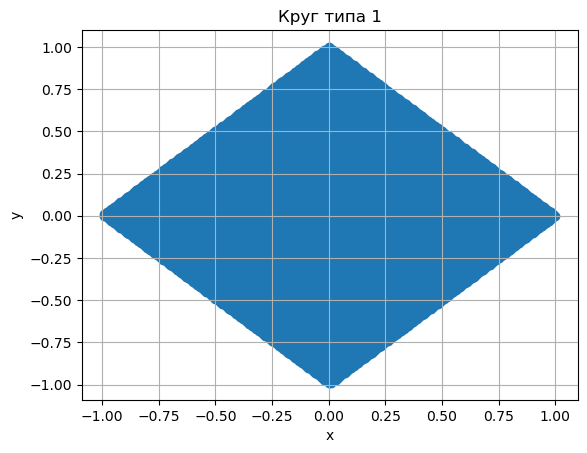

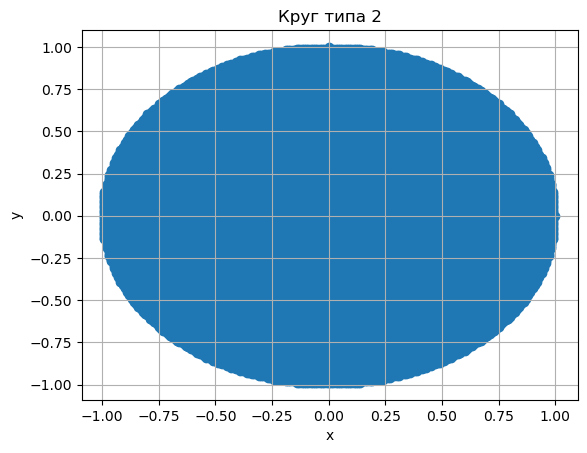

In [8]:
def M(radius, type):
    x = np.array([])
    y = np.array([])
    O = np.array([0,0])
    for Xc in np.arange(-5*radius, 5*radius, 0.01):
        for Yc in np.arange(-5*radius, 5*radius, 0.01):
            if p(np.array([Xc,Yc]), O, type) <= radius:
                x = np.append(x, Xc)
                y = np.append(y, Yc)
    plt.scatter(x,y)
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Круг типа " + str(type))
    plt.show()

M(1, 0)
M(1, 1)
M(1, 2)

**Упражнение 3**

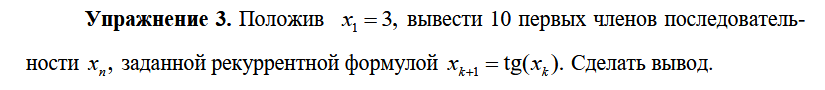

In [2]:
x1 = 3
for i in range(9):
    x1 = np.tan(x1)
    print(x1)

-0.1425465430742778
-0.14351994778492885
-0.14451354178374737
-0.14552803216462146
-0.14656416116305784
-0.14762270843290942
-0.14870449350594378
-0.14981037845185682
-0.15094127075832087


**Упражнение 4**

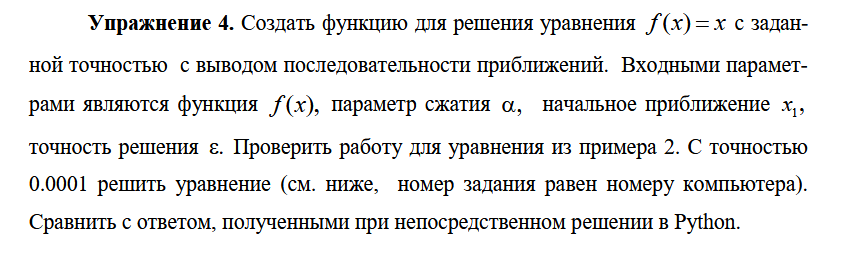

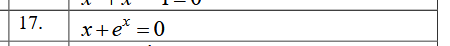

In [3]:
def solve_fixed_point(func, alpha, x1, epsilon):
    x2 = func(x1)
    p_x1_x2 = abs(x2 - x1)
    numerator = np.log(np.float64(epsilon * (1 - alpha))) - np.log(np.float64(p_x1_x2))
    denominator = np.log(alpha)
    n_required = int(np.ceil(numerator / denominator))

    curr_x = x1
    for i in range(1, n_required + 1):
        curr_x = func(curr_x)
    return curr_x


func = lambda x: -exp(x)

x = Symbol('x')
expr = -exp(x)
deriv = diff(expr, x)
alpha = float(Abs(deriv.subs(x, x1)).evalf())

x1 = -0.5
epsilon = 1e-8
solution = solve_fixed_point(func, alpha, x1, epsilon)
print(f"Решение: {solution}")
print(solution+np.e**(solution))

Решение: -0.567143290409784
1.11022302462516e-16


**Упражнение 5**

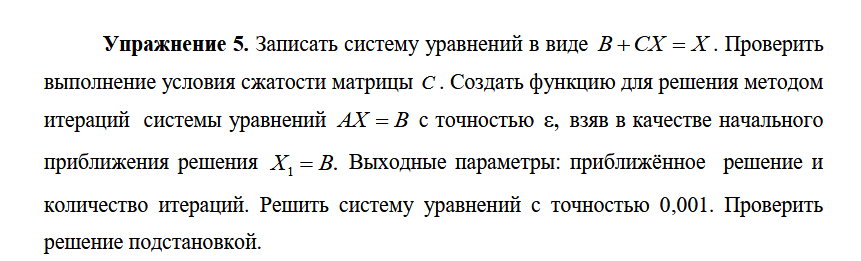

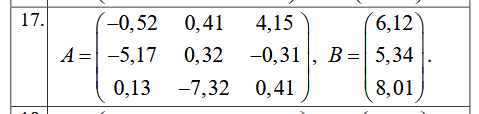

In [4]:
import numpy as np

def solve_system_auto(A, B, epsilon=0.001):
    n = len(B)
    permuted_indices = []
    unused_rows = list(range(n))
    
    for i in range(n):
        best_row = max(unused_rows, key=lambda r: abs(A[r, i]))
        permuted_indices.append(best_row)
        unused_rows.remove(best_row)
    
    A = A[permuted_indices]
    B = B[permuted_indices]
    
    C = np.zeros((n, n))
    D = np.zeros(n)
    
    for i in range(n):
        diag_element = A[i, i]
        D[i] = B[i] / diag_element
        for j in range(n):
            if i == j:
                C[i, j] = 0
            else:
                C[i, j] = -A[i, j] / diag_element

    alpha = np.max(np.sum(np.abs(C), axis=1))
    if alpha >= 1:
        print("Условие сжатости не выполнено")
    else:
        print("Условие сжатости выполнено")

    X = B.copy() 
    iterations = 0
    
    while True:
        X_new = C @ X + D
        iterations += 1
        
        error = np.linalg.norm(X_new - X, ord=np.inf)
        if error < epsilon:
            X = X_new
            break
        X = X_new
        
    return X, iterations, alpha


A = np.array([
    [-0.52,  0.41,  4.15],
    [-5.17,  0.32, -0.31],
    [ 0.13, -7.32,  0.41]
])
B = np.array([6.12, 5.34, 8.01])

x, iter, alpha = solve_system_auto(A, B)

print(f"Решение X: {x}")
print(f"Количество итераций: {iter}")
print(f"Проверка (AX - B): {np.dot(A, x) - B}")

Условие сжатости выполнено
Решение X: [-1.18261792 -1.03524134  1.42874772]
Количество итераций: 5
Проверка (AX - B): [-1.84599926e-04 -5.43988467e-05  1.28596732e-05]
